In [41]:
# 1 Import Libraries 
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import json
import warnings
warnings.filterwarnings("ignore")

# CONFIG
DATA_PATH = Path("processed_feature_selected.csv")
OUT_DIR = Path("output_final")
OUT_DIR.mkdir(exist_ok=True)
RANDOM_STATE = 42
TEST_SIZE = 0.2


In [59]:
# 2 Load Dataset 
print(" Loading dataset...")
df = pd.read_csv(DATA_PATH)
print("Loaded:", df.shape)

if "health_score" not in df.columns:
    raise ValueError("Missing 'health_score' column!")

# Create binary target
df["health_label"] = np.where(df["health_score"] > 0.5, "Healthy", "Unhealthy")
print("Target variable counts:\n", df["health_label"].value_counts())


 Loading dataset...
Loaded: (10619, 11)
Target variable counts:
 health_label
Healthy      5927
Unhealthy    4692
Name: count, dtype: int64


In [57]:
# 3 Select Features
drop_cols = ["title", "health_score", "fat_level"]
features = [c for c in df.columns if c not in drop_cols + ["health_label"]]
X = df[features]
y = df["health_label"]

print(f" Using {len(features)} features for training.")


 Using 8 features for training.


In [25]:
# 4 Train-Test Split & Scaling
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [49]:
# 5 Train Random Forest Model------------------------------
rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_test, y_pred)
print(f" Random Forest Accuracy: {rf_acc:.4f}")


 Random Forest Accuracy: 0.9840


In [51]:
# 6 Decision Tree + Hyperparameter Tuning
param_grid = {
    "max_depth": [3, 5, 8, 12, None],
    "min_samples_split": [2, 5, 10],
    "criterion": ["gini", "entropy"]
}

dt = DecisionTreeClassifier(random_state=RANDOM_STATE)
grid = GridSearchCV(dt, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
grid.fit(X_train, y_train)

best_dt = grid.best_estimator_
dt_pred = best_dt.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)

print(f" Best Decision Tree Accuracy: {dt_acc:.4f}")
print("Best Params:", grid.best_params_)


 Best Decision Tree Accuracy: 0.9798
Best Params: {'criterion': 'gini', 'max_depth': 12, 'min_samples_split': 2}


In [53]:
# 7 Cross-Validation + Model Comparison
rf_cv = cross_val_score(rf, X, y, cv=5, scoring="accuracy")
dt_cv = cross_val_score(best_dt, X, y, cv=5, scoring="accuracy")

print("\n Cross-validation mean accuracy:")
print(f"Random Forest: {rf_cv.mean():.4f}")
print(f"Decision Tree: {dt_cv.mean():.4f}")

if rf_cv.mean() >= dt_cv.mean():
    final_model = rf
    model_name = "RandomForest"
    final_acc = rf_cv.mean()
else:
    final_model = best_dt
    model_name = "DecisionTree"
    final_acc = dt_cv.mean()

print(f"\n Final Selected Model: {model_name} (Accuracy={final_acc:.4f})")



 Cross-validation mean accuracy:
Random Forest: 0.9830
Decision Tree: 0.9804

 Final Selected Model: RandomForest (Accuracy=0.9830)


In [55]:
# 8 Save Model + Reports
joblib.dump(final_model, OUT_DIR / f"{model_name}_final_model.pkl")
print(f" Model saved to: {OUT_DIR}/{model_name}_final_model.pkl")

report = classification_report(y_test, final_model.predict(X_test), output_dict=True)
with open(OUT_DIR / "classification_report.json", "w") as f:
    json.dump(report, f, indent=4)

cm = confusion_matrix(y_test, final_model.predict(X_test))
cm_df = pd.DataFrame(cm, index=final_model.classes_, columns=final_model.classes_)
cm_df.to_csv(OUT_DIR / "confusion_matrix.csv")

print("\n Classification report & confusion matrix saved successfully!")
print(" All outputs available in:", OUT_DIR)


 Model saved to: output_final/RandomForest_final_model.pkl

 Classification report & confusion matrix saved successfully!
 All outputs available in: output_final


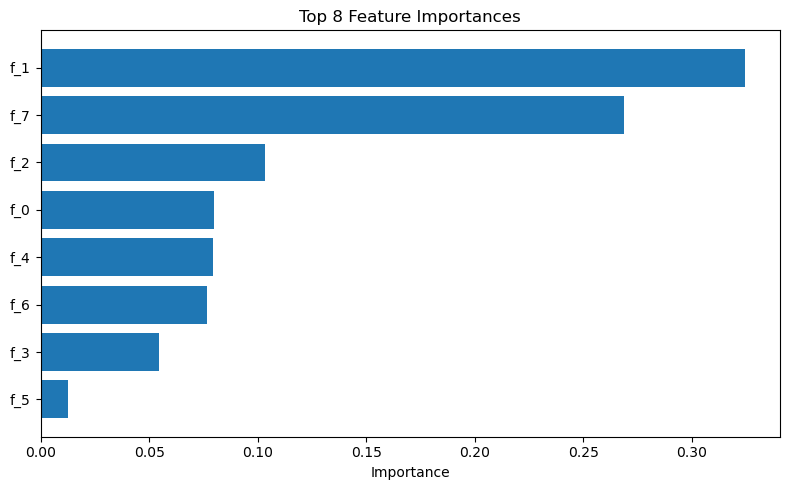

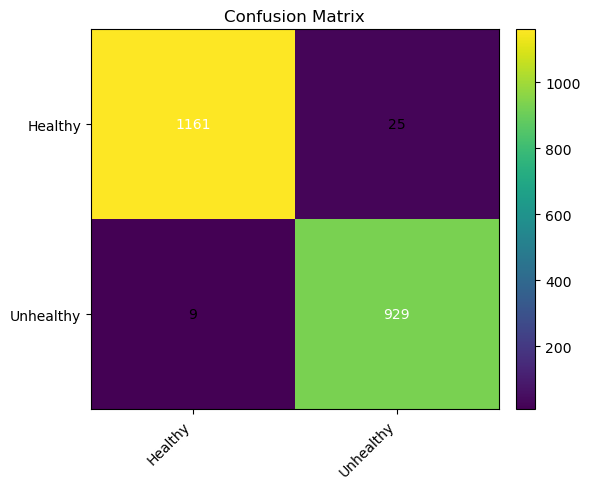

X_test/y_test not available — skipping accuracy/F1 plot.


In [12]:
# Visualization cell (feature)
import os
from pathlib import Path
import joblib
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, classification_report

OUT_DIR = Path("output_final")

# objects from notebook namespace
try:
    final_model  # noqa
    model_in_mem = True
except NameError:
    model_in_mem = False

# Load model if not in memory
if not model_in_mem and OUT_DIR.exists():
    # find a pkl file that looks like the final model
    pkl_files = list(OUT_DIR.glob("*final_model*.pkl")) + list(OUT_DIR.glob("*.pkl"))
    if pkl_files:
        try:
            final_model = joblib.load(pkl_files[0])
            print(f"Loaded model from: {pkl_files[0]}")
        except Exception as e:
            print("Could not load model:", e)

# get features list
try:
    features  # noqa
except NameError:
    # try load features from a saved JSON (if notebook saved it)
    features = None
    jf = OUT_DIR / "features.json"
    if jf.exists():
        try:
            features = json.load(open(jf, "r"))
            print("Loaded features from features.json")
        except:
            features = None

# Try to get confusion matrix dataframe (cm_df) or y_test/X_test
cm_df = globals().get("cm_df", None)
X_test = globals().get("X_test", None)
y_test = globals().get("y_test", None)

# If cm_df not available, attempt to load saved csv
if cm_df is None and (OUT_DIR / "confusion_matrix.csv").exists():
    try:
        cm_df = pd.read_csv(OUT_DIR / "confusion_matrix.csv", index_col=0)
        print("Loaded confusion_matrix.csv")
    except:
        cm_df = None

# If y_test/X_test not available, attempt to load test split (if saved)
if (X_test is None or y_test is None) and (OUT_DIR / "X_test.csv").exists():
    try:
        X_test = pd.read_csv(OUT_DIR / "X_test.csv", index_col=0)
        y_test = pd.read_csv(OUT_DIR / "y_test.csv", index_col=0).iloc[:,0]
        print("Loaded X_test.csv and y_test.csv")
    except Exception as e:
        print("Could not load X_test/y_test:", e)

# 1) Feature importances plot (if model exposes them)
fi = None
if hasattr(globals().get("final_model", None), "feature_importances_"):
    fi = final_model.feature_importances_
elif hasattr(globals().get("final_model", None), "coef_"):
    # for linear models
    coef = np.abs(final_model.coef_)
    if coef.ndim == 1:
        fi = coef
    else:
        fi = coef.mean(axis=0)

if fi is not None:
    # Align with features if available
    if features is not None and len(features) == len(fi):
        fi_series = pd.Series(fi, index=features)
    else:
        # fallback to numbered features
        fi_series = pd.Series(fi, index=[f"f_{i}" for i in range(len(fi))])

    fi_series = fi_series.sort_values(ascending=False)
    topk = min(10, len(fi_series))

    plt.figure(figsize=(8, 5))
    plt.barh(fi_series.index[:topk][::-1], fi_series.values[:topk][::-1])
    plt.xlabel("Importance")
    plt.title(f"Top {topk} Feature Importances")
    plt.tight_layout()
    plt.show()
else:
    print("Model does not expose feature_importances_ or coef_; skipping feature importance plot.")

# 2) Confusion matrix heatmap
if cm_df is None and (X_test is not None and y_test is not None and hasattr(final_model, "predict")):
    try:
        y_pred = final_model.predict(X_test)
        cm = confusion_matrix(y_test, y_pred)
        labels = np.unique(np.concatenate([y_test.unique() if hasattr(y_test, 'unique') else np.unique(y_test),
                                           final_model.classes_ if hasattr(final_model, 'classes_') else np.arange(cm.shape[0])]))
        cm_df = pd.DataFrame(cm, index=labels, columns=labels)
    except Exception as e:
        print("Could not compute confusion matrix:", e)

if cm_df is not None:
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm_df.values, interpolation='nearest', aspect='auto')
    ax.set_xticks(range(len(cm_df.columns)))
    ax.set_yticks(range(len(cm_df.index)))
    ax.set_xticklabels(cm_df.columns, rotation=45, ha="right")
    ax.set_yticklabels(cm_df.index)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    for (i, j), val in np.ndenumerate(cm_df.values):
        ax.text(j, i, int(val), ha='center', va='center', color='white' if val>cm_df.values.max()/2 else 'black')
    ax.set_title("Confusion Matrix")
    plt.tight_layout()
    plt.show()

    # Print classification report if possible
    if (X_test is not None and y_test is not None and hasattr(final_model, "predict")):
        y_pred = final_model.predict(X_test)
        print("\nClassification report (on X_test):")
        print(classification_report(y_test, y_pred))
else:
    print("No confusion matrix available to plot.")

# 3) Quick accuracy / macro-F1 bar (if y_test exists)
if X_test is not None and y_test is not None and hasattr(final_model, "predict"):
    y_pred = final_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    try:
        f1m = f1_score(y_test, y_pred, average='macro')
    except:
        f1m = None

    metrics = {"Accuracy": acc}
    if f1m is not None:
        metrics["Macro F1"] = f1m

    # bar plot
    plt.figure(figsize=(4,3))
    plt.bar(metrics.keys(), metrics.values())
    plt.ylim(0,1)
    plt.title("Evaluation Metrics on Test Set")
    for i,(k,v) in enumerate(metrics.items()):
        plt.text(i, v+0.02, f"{v:.3f}", ha='center')
    plt.tight_layout()
    plt.show()
else:
    print("X_test/y_test not available — skipping accuracy/F1 plot.")
